In [1]:
import kagglehub
from kagglehub import KaggleDatasetAdapter

import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import PolynomialFeatures
from sklearn.linear_model import LinearRegression

from sklearn.metrics import (
    mean_absolute_error,
    mean_squared_error,
    r2_score
)

In [5]:
file_path = "Position_Salaries.csv"

df = kagglehub.load_dataset(
    KaggleDatasetAdapter.PANDAS,
    "akram24/position-salaries",
    file_path
)

df.head()

/tmp/ipykernel_6001/1892674228.py:3: DeprecationWarning: Use dataset_load() instead of load_dataset(). load_dataset() will be removed in a future version.
  df = kagglehub.load_dataset(


Using Colab cache for faster access to the 'position-salaries' dataset.


,Position,Level,Salary
0,Business Analyst,1,45000
1,Junior Consultant,2,50000
2,Senior Consultant,3,60000
3,Manager,4,80000
4,Country Manager,5,110000


In [6]:
df.describe()

,Level,Salary
count,10.00000,10.000000
mean,5.50000,249500.000000
std,3.02765,299373.883668
min,1.00000,45000.000000
25%,3.25000,65000.000000
50%,5.50000,130000.000000
75%,7.75000,275000.000000
max,10.00000,1000000.000000


In [7]:
df.isnull().sum()
X = df[['Level']]
y = df['Salary']
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42
)
poly = PolynomialFeatures(degree=3)

X_train_poly = poly.fit_transform(X_train)
X_test_poly = poly.transform(X_test)

In [10]:
poly = PolynomialFeatures(degree=3)

X_train_poly = poly.fit_transform(X_train)
X_test_poly = poly.transform(X_test)
model = LinearRegression()

model.fit(X_train_poly, y_train)
y_pred = model.predict(X_test_poly)
mae = mean_absolute_error(y_test, y_pred)

print("MAE :", mae)
mse = mean_squared_error(y_test, y_pred)

print("MSE :", mse)
r2 = r2_score(y_test, y_pred)

print("R² Score :", r2)

MAE : 70635.24590164085
MSE : 6263853282.860292
R² Score : 0.8762695647830065


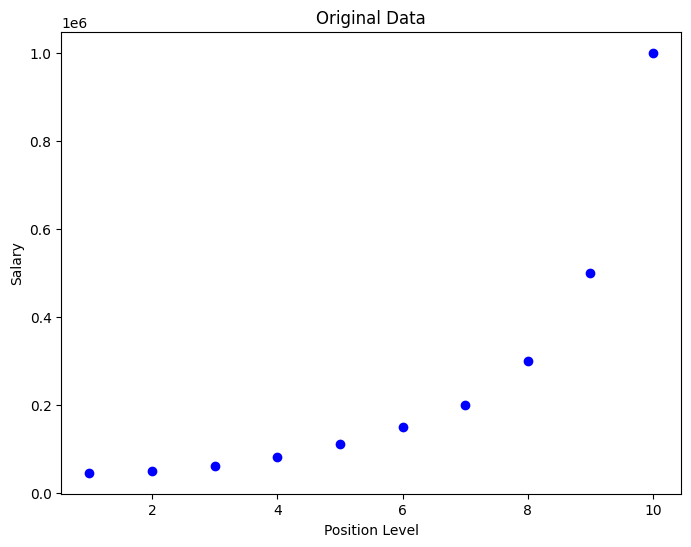

In [11]:
plt.figure(figsize=(8,6))

plt.scatter(X, y,color="blue")

plt.xlabel("Position Level")
plt.ylabel("Salary")
plt.title("Original Data")

plt.show()

/tmp/ipykernel_6001/550250879.py:1: DeprecationWarning: Conversion of an array with ndim > 0 to a scalar is deprecated, and will error in future. Ensure you extract a single element from your array before performing this operation. (Deprecated NumPy 1.25.)
  X_grid = np.arange(min(X.values),max(X.values),0.1)
/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but PolynomialFeatures was fitted with feature names
  warnings.warn(


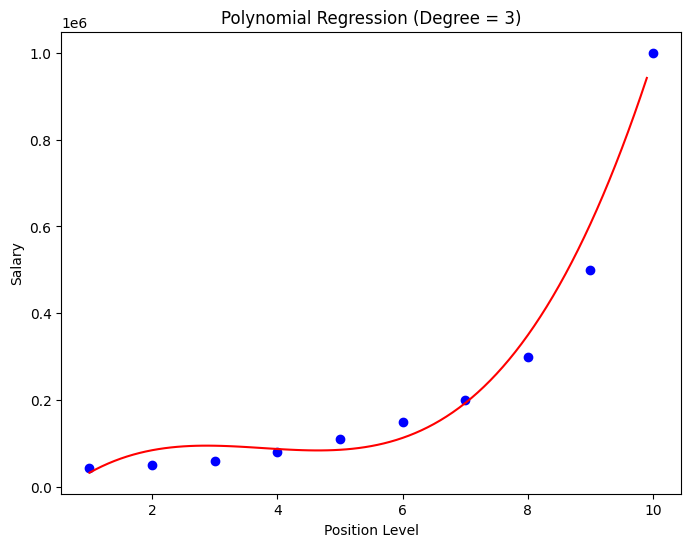

In [14]:
X_grid = np.arange(min(X.values),max(X.values),0.1)
X_grid = X_grid.reshape(len(X_grid),1)

plt.figure(figsize=(8,6))

plt.scatter(X,y,color="blue")

plt.plot(
    X_grid,
    model.predict(poly.transform(X_grid)),
    color="red"
)

plt.xlabel("Position Level")
plt.ylabel("Salary")
plt.title("Polynomial Regression (Degree = 3)")

plt.show()